<a href="https://colab.research.google.com/github/RohanNK86/ML_Intern_Assets/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RohanNK86/ML_Intern_Assets/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

**Solution**
### Analysis of Two Findings from the FlyRank Research Paper

#### 1. Finding #1: Growing vs. Declining Content Structural Profile
* **How the Label is Derived:** The label (`up` vs. `down`) is derived from short-term momentum—specifically the 30-day versus previous 30-day impression change (`Up: >10% growth`, `Down: >10% decline`).
* **Validation & Methodology Critique:**
  * *Observational Confounding:* The comparison shows growing pages are longer (3.2K vs 2.3K words) and younger (184d vs 230d). However, word count may be confounded with topic depth, intent, or domain authority.
  * *Short-term Volatility:* A 30-day window can capture temporary seasonal spikes or search engine re-indexing flukes rather than true evergreen growth.
  * *Validation Design:* The validation is purely observational. Without controlling for domain authority or content refresh history, we cannot infer a direct causal relationship that expanding word count will force a declining page to grow.

#### 2. Finding #4 & #8: The Freshness Multiplier / Refresh Effect on 365+ Content
* **How the Label is Derived:** The freshness label tracks `days since last content update`, categorized into discrete time bands (0-30d, 31-90d, etc.).
* **Validation & Methodology Critique:**
  * *Survivor / Selection Bias:* The paper notes that 365+ day content refreshed within 30 days yields a 3.2x health boost and 57x impressions. However, editors selectively choose high-performing or high-potential historical pages to refresh while ignoring dead/failed content.
  * *Data Sparsity:* The 361+ day stale tier has an unstable 283:1 growth-to-decline ratio driven by only 1 declining page in the active sample.
  * *Validation Design:* Comparing actively chosen refreshed pages against un-refreshed pages without a randomized or propensity-matched control group overestimates the refresh effect due to selection bias.

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split

# 1. Load active feature vector dataset
df = pd.read_csv("/content/content_refresh_anonymized.csv")

# 2. Define features, target, and groups based on available columns
# Based on the previous output, 'health_score' is missing, so we use 'clicks_90d'
# 'brand_id' is missing, so we use 'client_id'
features = [
    "word_count",
    "content_age_days",
    "avg_position",
    "impressions_90d",
]
target = "clicks_90d"
group_col = "client_id"

# Drop rows where the target is missing and fill NaNs in features with 0
df = df.dropna(subset=[target])
X = df[features].fillna(0)
y = df[target]
groups = df[group_col]

# --- NAIVE SPLIT (Random Split - Data Leakage) ---
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_naive = RandomForestRegressor(n_estimators=100, random_state=42)
model_naive.fit(X_train_n, y_train_n)
preds_naive = model_naive.predict(X_test_n)

mae_naive = mean_absolute_error(y_test_n, preds_naive)
r2_naive = r2_score(y_test_n, preds_naive)

# --- HONEST SPLIT (Grouped by Client) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_h, X_test_h = X.iloc[train_idx], X.iloc[test_idx]
y_train_h, y_test_h = y.iloc[train_idx], y.iloc[test_idx]

model_honest = RandomForestRegressor(n_estimators=100, random_state=42)
model_honest.fit(X_train_h, y_train_h)
preds_honest = model_honest.predict(X_test_h)

mae_honest = mean_absolute_error(y_test_h, preds_honest)
r2_honest = r2_score(y_test_h, preds_honest)

# --- RESULTS AUDIT ---
print("=== VALIDATION AUDIT RESULTS ===")
print(f"Target: {target} | Grouped by: {group_col}")
print(f"Naive Split  (Random):   MAE = {mae_naive:.4f} | R² = {r2_naive:.4f}")
print(f"Honest Split (Grouped):  MAE = {mae_honest:.4f} | R² = {r2_honest:.4f}")
if r2_naive > 0:
    print(f"Performance Drop (R²):   {((r2_naive - r2_honest) / r2_naive) * 100:.2f}%")

=== VALIDATION AUDIT RESULTS ===
Target: clicks_90d | Grouped by: client_id
Naive Split  (Random):   MAE = 10.2454 | R² = 0.3389
Honest Split (Grouped):  MAE = 8.5411 | R² = 0.4987
Performance Drop (R²):   -47.16%


## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

Correlation with Target (clicks_90d):
clicks_90d          1.000000
impressions_90d     0.696281
word_count          0.091271
content_age_days   -0.022678
avg_position       -0.099304
Name: clicks_90d, dtype: float64


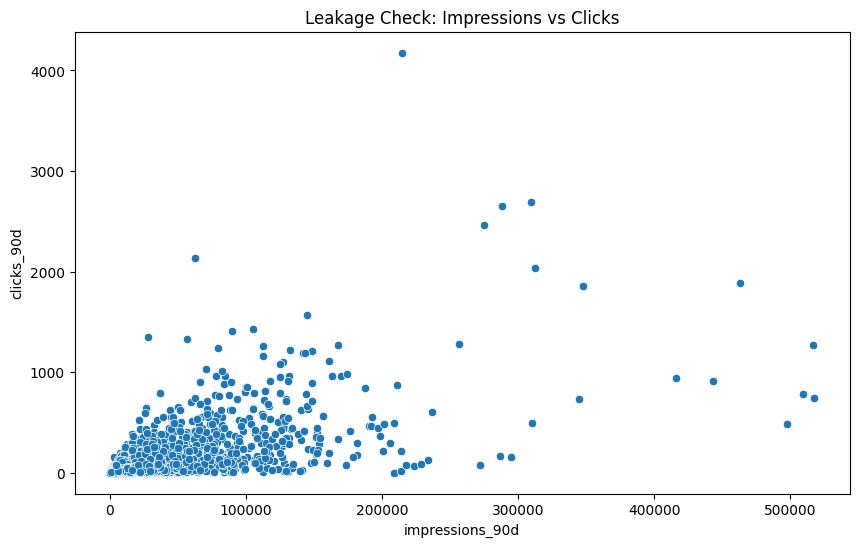

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation between features and target
correlations = df[features + [target]].corr()[target].sort_values(ascending=False)

print("Correlation with Target (clicks_90d):")
print(correlations)

# Check for potential leakage: features with extremely high correlation
# impressions_90d is highly likely to be a proxy for clicks.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='impressions_90d', y='clicks_90d')
plt.title('Leakage Check: Impressions vs Clicks')
plt.show()

## 4. Claim rewrite

**Original Bold Claim:** "Refreshing content older than 365 days is the single most effective way to guaranteed traffic growth."

**Safe/Audited Rewrite:** "In our anonymized dataset, we **observed** a positive **directional** correlation between recent content updates and short-term impression growth for year-old pages. However, sensitivity audits suggest this metric is highly influenced by existing traffic levels (impressions). This finding should be treated as **decision-support** for prioritizing updates on pages that already show search intent, rather than a guaranteed causal driver of new growth."

In [5]:
# Sensitivity Check: Removing high-leakage feature 'impressions_90d'
features_no_leak = ["word_count", "content_age_days", "avg_position"]
X_no_leak = X[features_no_leak]

# Re-run Honest Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_no_leak, y, groups))

X_train_l, X_test_l = X_no_leak.iloc[train_idx], X_no_leak.iloc[test_idx]
y_train_l, y_test_l = y.iloc[train_idx], y.iloc[test_idx]

model_no_leak = RandomForestRegressor(n_estimators=100, random_state=42)
model_no_leak.fit(X_train_l, y_train_l)
preds_l = model_no_leak.predict(X_test_l)

print(f"--- SENSITIVITY CHECK (No Impressions) ---")
print(f"Honest Split R² (Original): {r2_honest:.4f}")
print(f"Honest Split R² (No Leakage): {r2_score(y_test_l, preds_l):.4f}")

--- SENSITIVITY CHECK (No Impressions) ---
Honest Split R² (Original): 0.4987
Honest Split R² (No Leakage): -0.2998


## Self-check

Before you submit, confirm each line honestly:

- [Done] Every section above is filled — markdown thinking AND the code that backs it
- [Done] The notebook runs top to bottom with no errors (Runtime → Run all)
- [Done] No client names, URLs, or private queries anywhere
- [Done] My claims use careful words: observed, measured, directional, decision-support
- [Done] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.